### API Tutorial for Accessing IllustrisTNG Data

In [2]:
import requests

# initiate API request
api_key = "9cdee6b224d720db0fa834718d61e0d0"
baseUrl = "http://www.tng-project.org/api/" # rerun okay on https instead of http
headers = {"api-key": api_key}

def get(path, params=None):
    
    if "http" in path:
        path = path.replace("http", "https")

    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == "application/json":
        return r.json() # parse json responses automatically
    
    return r

In [3]:
r = get(path=baseUrl) 

In [4]:
# verify if output is a dictionary object with one key "simulations"
print(r.keys()); print(len(r['simulations']))

dict_keys(['simulations'])
66


In [5]:
# peek into the structure of the API keys by accessing the first entry
r['simulations'][0]

{'name': 'Illustris-1',
 'num_snapshots': 134,
 'url': 'http://www.tng-project.org/api/Illustris-1/'}

In [6]:
sim_names = [sim["name"] for sim in r["simulations"]]
print(sim_names)

['Illustris-1', 'Illustris-1-Dark', 'Illustris-2', 'Illustris-2-Dark', 'Illustris-3', 'Illustris-3-Dark', 'TNG100-1', 'TNG100-1-Dark', 'TNG100-2', 'TNG100-2-Dark', 'TNG100-3', 'TNG100-3-Dark', 'TNG300-3', 'TNG300-2-Dark', 'TNG300-2', 'TNG300-1-Dark', 'TNG300-1', 'TNG300-3-Dark', 'TNG50-1', 'TNG50-1-Dark', 'TNG50-2', 'TNG50-2-Dark', 'TNG50-3', 'TNG50-3-Dark', 'TNG50-4', 'TNG50-4-Dark', 'TNG-Cluster', 'Illustris-1-Subbox0', 'Illustris-1-Subbox1', 'Illustris-1-Subbox2', 'Illustris-1-Subbox3', 'Illustris-2-Subbox0', 'Illustris-2-Subbox1', 'Illustris-2-Subbox2', 'Illustris-2-Subbox3', 'Illustris-3-Subbox0', 'Illustris-3-Subbox1', 'Illustris-3-Subbox2', 'Illustris-3-Subbox3', 'TNG100-1-Subbox0', 'TNG100-1-Subbox1', 'TNG100-2-Subbox0', 'TNG100-2-Subbox1', 'TNG100-3-Subbox0', 'TNG100-3-Subbox1', 'TNG300-3-Subbox1', 'TNG300-3-Subbox2', 'TNG300-3-Subbox0', 'TNG300-2-Subbox1', 'TNG300-2-Subbox2', 'TNG300-2-Subbox0', 'TNG300-1-Subbox1', 'TNG300-1-Subbox2', 'TNG300-1-Subbox0', 'TNG50-1-Subbox0', 'T

In [7]:
# sample implementation of getting metadata of specific simulations, taking for example Illustris-1
i = sim_names.index('Illustris-3')

sample_sim = get(path=r['simulations'][i]['url'])
print(sample_sim.keys())
print(sample_sim['num_dm'])

dict_keys(['name', 'description', 'name_alt', 'boxsize', 'z_start', 'z_final', 'cosmology', 'omega_0', 'omega_L', 'omega_B', 'hubble', 'physics_model', 'has_cooling', 'has_starformation', 'has_winds', 'has_blackholes', 'mass_gas', 'mass_dm', 'softening_dm_comoving', 'softening_stars_comoving', 'softening_blackholes_comoving', 'softening_gas_comoving', 'softening_dm_max_phys', 'softening_stars_max_phys', 'softening_blackholes_max_phys', 'softening_gas_max_phys', 'softening_gas_factor', 'softening_gas_comoving_min', 'num_dm', 'num_tr_mc', 'num_tr_vel', 'longids', 'is_uniform', 'is_zoom', 'is_subbox', 'num_files_snapshot', 'num_files_groupcat', 'num_files_rockstar', 'num_files_lhalotree', 'num_files_sublink', 'num_files_ctrees', 'filesize_lhalotree', 'filesize_sublink', 'filesize_ctrees', 'filesize_ics', 'filesize_simulation', 'has_fof', 'has_subfind', 'has_rockstar', 'has_lhalotree', 'has_sublink', 'has_ctrees', 'permission_required', 'num_snapshots', 'url', 'parent_simulation', 'child_s

In [8]:
sample_sim['snapshots']
sample_snaps = get(path=sample_sim['snapshots'])

# check last element of snapshot, corresponding to z=0 or present day
sample_snaps[-1]

{'number': 135,
 'redshift': 2.2204460492503099e-16,
 'num_groups_subfind': 121209,
 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/'}

In [9]:
# full metadata for the sample snapshot
sample_snap = get(path=sample_snaps[-1]['url'])
sample_snap

{'simulation': 'http://www.tng-project.org/api/Illustris-3/',
 'number': 135,
 'redshift': 2.2204460492503099e-16,
 'num_gas': 87571556,
 'num_dm': 94196375,
 'num_trmc': 94196375,
 'num_stars': 4388167,
 'num_bhs': 33582,
 'num_groups_fof': 131727,
 'num_groups_subfind': 121209,
 'num_groups_rockstar': 0,
 'filesize_snapshot': 23437820660.0,
 'filesize_groupcat': 114056740.0,
 'filesize_rockstar': 0.0,
 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/',
 'subhalos': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/',
 'vis': {'groupcat_sfms': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/plot.png?xQuant=mstar2_log&yQuant=ssfr&xlim=9.0%2C11.0',
  'groupcat_sizemass': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/plot.png?xQuant=mstar2_log&yQuant=size_stars',
  'groupcat_mz_gas': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/plot.png?xQuant=mstar2_log&yQuant=Z_gas',
  'groupcat_mz_stars': '

In [10]:
# request for the subhalo endpoints
sample_subs = get(sample_snap['subhalos'])
print(sample_subs.keys())
print(sample_subs['count'])
print(sample_subs['next'])
print(len(sample_subs['results']))

dict_keys(['count', 'next', 'previous', 'results'])
121209
http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/?limit=100&offset=100
100


In [11]:
# subhalos by default are paginated by 100 by default, but can be modified using the limit parameter
sample_subs = get(sample_snap['subhalos'], {'limit':220})
print(len(sample_subs['results']))
print(sample_subs['next'])
print(sample_subs['results'][0])

220
http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/?limit=220&offset=220
{'id': 0, 'sfr': 4.11098, 'mass_log_msun': 14.554690443287308, 'url': 'http://www.tng-project.org/api/Illustris-3/snapshots/135/subhalos/0/'}


In [12]:
# Note that the return order of the subhalos are arbitrary unless specified; negative sign means descending order
sample_subs = get(path=sample_snap['subhalos'], params={'limit':20, 'order_by':'-mass_stars'})

print(len(sample_subs['results']))

print([sample_subs['results'][i]['id'] for i in range(5)])

20
[0, 1030, 2074, 2302, 2843]


In [13]:
# check getting info for some ID == 1030, imitated from the tutorial
sub = get(path=sample_subs['results'][1]['url'])
sub

{'snap': 135,
 'id': 1030,
 'bhmdot': 0.199144,
 'cm_x': 10992.8,
 'cm_y': 50807.7,
 'cm_z': 47671.3,
 'gasmetallicity': 0.00787963,
 'gasmetallicityhalfrad': 0.0167215,
 'gasmetallicitymaxrad': 0.053106,
 'gasmetallicitysfr': 0.0510764,
 'gasmetallicitysfrweighted': 0.0518217,
 'pos_x': 10908.2,
 'pos_y': 50865.5,
 'pos_z': 47651.8,
 'halfmassrad': 527.237,
 'halfmassrad_gas': 660.879,
 'halfmassrad_dm': 510.476,
 'halfmassrad_stars': 50.759,
 'halfmassrad_bhs': 0.0,
 'len': 1113373,
 'len_gas': 448911,
 'len_dm': 624445,
 'len_stars': 39946,
 'len_bhs': 71,
 'mass': 20463.1,
 'mass_gas': 2678.49,
 'mass_dm': 17620.2,
 'mass_stars': 158.333,
 'mass_bhs': 6.04079,
 'massinhalfrad': 496.772,
 'massinhalfrad_gas': 5.39936,
 'massinhalfrad_dm': 406.895,
 'massinhalfrad_stars': 79.1619,
 'massinhalfrad_bhs': 5.31633,
 'massinmaxrad': 5.28624,
 'massinmaxrad_gas': 0.007397,
 'massinmaxrad_dm': 0.0,
 'massinmaxrad_stars': 0.015315,
 'massinmaxrad_bhs': 5.26353,
 'massinrad': 1352.77,
 'massi

In [14]:
url = sub['related']['parent_halo'] + "info.json"
url

'http://www.tng-project.org/api/Illustris-3/snapshots/135/halos/2/info.json'

In [15]:
parent_fof = get(path=url)
parent_fof.keys()

dict_keys(['SimulationName', 'SnapshotNumber', 'InfoType', 'InfoID', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupFuzzOffsetType', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'StellarMasses', 'TracerLength', 'TracerOffset'])

In [16]:
# key/column Group no longer available. must now specify group catalog
print(parent_fof['GroupFirstSub'])
print(parent_fof['GroupPos'])


1030
[10908.2392578125, 50865.515625, 47651.7890625]


In [17]:
# redefine get function to include request of the HDF5 file
def get(path, params=None):
    # convert http to https
    if "http" in path:
        path = path.replace("http", "https")

    r = requests.get(path, params=params, headers=headers)

    # raise exceptions if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string
    
    return r

In [18]:
import h5py

mpb1 = get(sub['trees']['sublink_mpb'])

f = h5py.File(mpb1, 'r')

print(f.keys())

<KeysViewHDF5 ['DescendantID', 'FirstProgenitorID', 'FirstSubhaloInFOFGroupID', 'Group_M_Crit200', 'Group_M_Mean200', 'Group_M_TopHat200', 'LastProgenitorID', 'MainLeafProgenitorID', 'Mass', 'MassHistory', 'NextProgenitorID', 'NextSubhaloInFOFGroupID', 'NumParticles', 'RootDescendantID', 'SnapNum', 'SubfindID', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloCM', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasMetallicityMaxRad', 'SubhaloGasMetallicitySfr', 'SubhaloGasMetallicitySfrWeighted', 'SubhaloGrNr', 'SubhaloHalfmassRad', 'SubhaloHalfmassRadType', 'SubhaloID', 'SubhaloIDMostbound', 'SubhaloIDRaw', 'SubhaloLen', 'SubhaloLenType', 'SubhaloMass', 'SubhaloMassInHalfRad', 'SubhaloMassInHalfRadType', 'SubhaloMassInMaxRad', 'SubhaloMassInMaxRadType', 'SubhaloMassInRad', 'SubhaloMassInRadType', 'SubhaloMassType', 'SubhaloParent', 'SubhaloPos', 'SubhaloSFR', 'SubhaloSFRinHalfRad', 'SubhaloSFRinMaxRad', 'SubhaloSFRinRad', 'SubhaloSpin', 'SubhaloStarMetallicity', 'SubhaloStar

In [19]:
print(len(f['SnapNum']))

104


In [20]:
print(f['SnapNum'][:])

[135 134 133 132 131 130 129 128 127 126 125 124 123 122 121 120 119 118
 117 116 115 114 113 112 111 110 109 108 107 106 105 104 103 102 101 100
  99  98  97  96  95  94  93  92  91  90  89  88  87  86  85  84  83  82
  81  80  79  78  77  76  75  74  73  72  71  70  69  68  67  66  65  64
  63  62  61  60  59  58  57  56  55  54  53  52  51  50  49  48  47  46
  45  44  43  42  41  40  39  38  37  36  35  34  33  32]


In [21]:
f.close()

In [22]:
mpb2 = get(sub['trees']['lhalotree_mpb']) # file saved, mpb2 contains the filename

with h5py.File(mpb2, 'r') as f:
    print(len(f['SnapNum']))

104


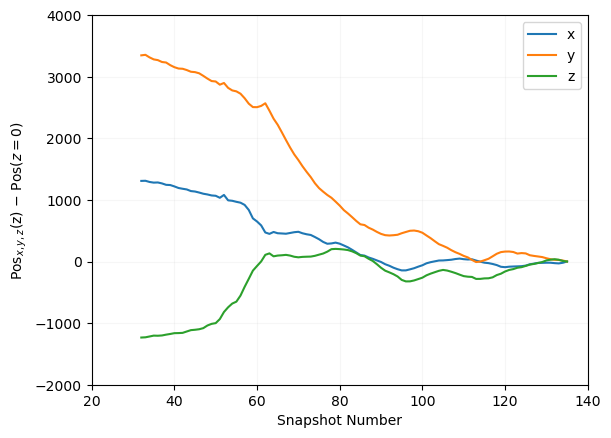

In [23]:
import matplotlib.pyplot as plt

with h5py.File(mpb2, 'r') as f:
    pos = f['SubhaloPos'][:]
    snapnum = f['SnapNum'][:]
    subid = f['SubhaloNumber'][:]

for i in range(3):
    plt.plot(snapnum, pos[:,i] - pos[0,i], label=['x', 'y', 'z'][i])

plt.legend()
plt.xlabel('Snapshot Number')
plt.ylabel(r'Pos$_{x,y,z}$(z) $-$ Pos($z=0$)')
plt.grid(alpha=0.1)

plt.ylim(-2000, 4000)
plt.xlim(20, 140)

plt.show()

We can now reconstruct the gas density around the $z=1$ progenitor of our subhalo

In [24]:
url = sample_sim['snapshots'] + "z=1"
url

'http://www.tng-project.org/api/Illustris-3/snapshots/z=1'

In [25]:
snap = get(path=url)
snap['number'], snap['redshift']

(85, 0.9972942257819399)

In [26]:
import numpy as np

# find the target Subfind ID at snapshot 85 using the Sublink tree
i = np.where(snapnum == 85)
subid[i]

array([185], dtype=int32)

In [27]:
# request the subhalo details, and a snapshot cutout consisting only of Gas fields Coordinates, Masses
sub_prog_url = "http://www.tng-project.org/api/Illustris-3/snapshots/85/subhalos/185/"
sub_prog = get(path=sub_prog_url)
sub_prog['pos_x'], sub_prog['pos_y']

(11013.3, 51469.6)

In [28]:
cutout_request = {'gas':'Coordinates,Masses'}
cutout = get(path = sub_prog_url + "cutout.hdf5", params=cutout_request)

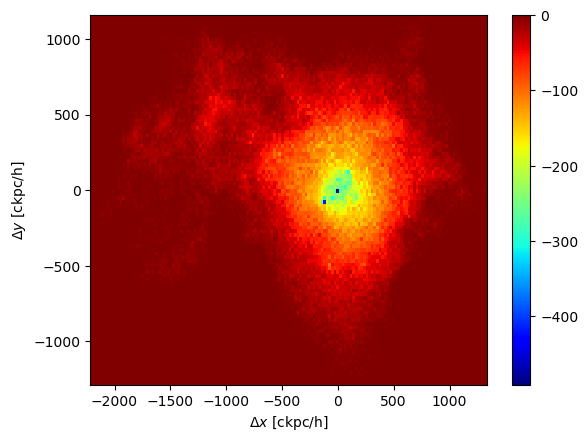

In [29]:
with h5py.File(cutout, 'r') as f:
    x = f['PartType0']['Coordinates'][:,0] - sub_prog['pos_x']
    y = f['PartType0']['Coordinates'][:,1] - sub_prog['pos_y']
    dens = np.log10(f['PartType0']['Masses'][:])

counts, xedges, yedges, image = plt.hist2d(x, y, weights=dens, bins=[150,100], cmap='jet')
plt.xlabel("$\Delta x$ [ckpc/h]")
plt.ylabel("$\Delta y$ [ckpc/h]")

plt.colorbar(image)

plt.show()

### Task 2 Sample Tutorial

In [30]:
# first convert log solar masses into group catalog units
mass_min = 10**11.9 / 1e10 * 0.704
mass_max = 10**12.1 / 1e10 * 0.704

# form the search_query string by hand for once
search_query = "?mass__gt=" + str(mass_min) + "&mass__lt=" + str(mass_max)
search_query



'?mass__gt=55.920707724589455&mass__lt=88.6283489903093'

In [31]:
# form the url and make the request
url = "http://www.tng-project.org/api/Illustris-1/snapshots/z=2/subhalos/" + search_query
#url = "http://www.tng-project.org/api/Illustris-1/snapshots/z=2/subhalos"
subhalos = get(url)



In [35]:
subhalos['count']

550

In [33]:
ids = [subhalos['results'][i]['id'] for i in range(5)]
ids

[1, 1352, 5525, 6574, 12718]